<a href="https://colab.research.google.com/github/Manikanta2804/RL_ASSESMENTS_2303A51458_B_07/blob/main/RL_ASSESMENT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objective
Implement the Upper Confidence Bound (UCB) for a Multi-Armed Bandit problem and estimate the future reward (Q-value) of each machine using the incremental sample-average method.

### Part A – Machine Initialization
Initialize the machine names, total number of plays, and dictionaries to store the number of times each machine has been played (`N`), the total reward obtained from each machine (`R`), and the estimated Q-value (average reward) for each machine (`Q`).

In [1]:
# Part A – Machine Initialization
machines = ['A', 'B', 'C']
M = len(machines)  # Number of machines
N_play = 10        # Number of plays
c = 2              # Exploration parameter for UCB, commonly sqrt(2) but here simplified to 2

# Initialize N, R, Q tables as dictionaries
N = {machine: 0 for machine in machines}  # Number of times each machine has been played
R = {machine: 0 for machine in machines}  # Total reward from each machine
Q = {machine: 0.0 for machine in machines} # Estimated Q-value (average reward) for each machine

# UCB values will be calculated per play, so no need to pre-initialize a table for it

print("Initialization complete:")
print(f"Machines: {machines}")
print(f"Number of plays: {N_play}")
print(f"Initial N: {N}")
print(f"Initial R: {R}")
print(f"Initial Q: {Q}")

Initialization complete:
Machines: ['A', 'B', 'C']
Number of plays: 10
Initial N: {'A': 0, 'B': 0, 'C': 0}
Initial R: {'A': 0, 'B': 0, 'C': 0}
Initial Q: {'A': 0.0, 'B': 0.0, 'C': 0.0}


### Part B, C, D, E – Main Simulation Loop
This section contains the core logic for the Multi-Armed Bandit simulation over `N_play` iterations:

*   **Part B:** Implicitly handled within the loop by updating `N`, `R`, and `Q` based on each play.
*   **Part C – UCB Calculation and Machine Selection:** For each play, the Upper Confidence Bound (UCB) is calculated for every machine. The machine with the highest UCB value is then chosen.
    *   The UCB formula used is `Q(a) + c * sqrt(ln(t) / N(a))`, where `t` is the current play number.
    *   To handle machines not yet played (`N(a) = 0`), their UCB is set to `float('inf')` to ensure they are picked at least once.
*   **Part D – Reward Collection:** The program prompts the user to enter the reward obtained from the selected machine.
*   **Part E – Q-Value Update:** The Q-value of the selected machine is updated using the incremental sample-average formula:
    `Q(a)_new = Q(a)_old + (1 / N(a)) * (Reward - Q(a)_old)`

In [6]:
# Part B, C, D, E – Main Simulation Loop
import math

# List to store UCB values for each play for later display
ucb_history = []

for t in range(1, N_play + 1):  # t is the current play number
    print(f"\n--- Play {t}/{N_play} ---")
    current_ucb = {}

    # Part C – UCB Calculation
    for machine in machines:
        if N[machine] == 0: # If a machine hasn't been played yet, give it an infinite UCB to ensure exploration
            current_ucb[machine] = float('inf')
        else:
            # UCB formula: Q(a) + c * sqrt(ln(t) / N(a))
            exploration_term = c * math.sqrt(math.log(t) / N[machine])
            current_ucb[machine] = Q[machine] + exploration_term

    ucb_history.append(current_ucb) # Store UCB values for this play
    print(f"Calculated UCB values for Play {t}: {current_ucb}")

    # Choose machine with the highest UCB value
    selected_machine = max(current_ucb, key=current_ucb.get)
    print(f"Selected machine for Play {t}: {selected_machine}")

    # Part D – Reward Collection
    while True:
        try:
            reward = float(input(f"Enter reward for machine {selected_machine}: "))
            break
        except ValueError:
            print("Invalid input. Please enter a numerical reward.")

    # Part E – Q-Value Update
    N[selected_machine] += 1 # Update participation count
    R[selected_machine] += reward # Update total reward

    # Incremental sample-average formula
    Q[selected_machine] = Q[selected_machine] + (1 / N[selected_machine]) * (reward - Q[selected_machine])

    print(f"Updated N: {N}")
    print(f"Updated R: {R}")
    print(f"Updated Q: {Q}")


--- Play 1/10 ---
Calculated UCB values for Play 1: {'A': 5.333333333333334, 'B': 2.0, 'C': 3.0}
Selected machine for Play 1: A
Enter reward for machine A: 1
Updated N: {'A': 4, 'B': 1, 'C': 1}
Updated R: {'A': 17.0, 'B': 2.0, 'C': 3.0}
Updated Q: {'A': 4.25, 'B': 2.0, 'C': 3.0}

--- Play 2/10 ---
Calculated UCB values for Play 2: {'A': 5.082554611157698, 'B': 3.6651092223153956, 'C': 4.665109222315396}
Selected machine for Play 2: A
Enter reward for machine A: 2
Updated N: {'A': 5, 'B': 1, 'C': 1}
Updated R: {'A': 19.0, 'B': 2.0, 'C': 3.0}
Updated Q: {'A': 3.8, 'B': 2.0, 'C': 3.0}

--- Play 3/10 ---
Calculated UCB values for Play 3: {'A': 4.737491243124163, 'B': 4.09629414793641, 'C': 5.09629414793641}
Selected machine for Play 3: C
Enter reward for machine C: 3
Updated N: {'A': 5, 'B': 1, 'C': 2}
Updated R: {'A': 19.0, 'B': 2.0, 'C': 6.0}
Updated Q: {'A': 3.8, 'B': 2.0, 'C': 3.0}

--- Play 4/10 ---
Calculated UCB values for Play 4: {'A': 4.8531075390936635, 'B': 4.35482004503095, 'C

KeyboardInterrupt: Interrupted by user

### Part F – Display Results and Total Reward
Finally, display the `N`, `R`, and `Q` tables, as well as the UCB values calculated during each play. Also, calculate and display the total reward received by the player across all plays.

In [7]:
# Part F – Display Results
import pandas as pd

print("\n--- Final Results ---")

# Display N (Participation Count) Table
n_df = pd.DataFrame.from_dict(N, orient='index', columns=['Participation Count'])
print("\nParticipation Count (N) Table:")
display(n_df)

# Display R (Total Rewards) Table
r_df = pd.DataFrame.from_dict(R, orient='index', columns=['Total Reward'])
print("\nTotal Rewards (R) Table:")
display(r_df)

# Display Q (Estimated Q-Values) Table
q_df = pd.DataFrame.from_dict(Q, orient='index', columns=['Estimated Q-Value'])
print("\nEstimated Q-Values (Q) Table:")
display(q_df)

# Display UCB History (optional, if you want to see how UCB evolved)
print("\nUCB Values History per Play:")
for i, ucb_vals in enumerate(ucb_history):
    print(f"Play {i+1}: {ucb_vals}")

# Calculate total reward the player received
total_reward_player = sum(R.values())
print(f"\nTotal reward the player received: {total_reward_player}")


--- Final Results ---

Participation Count (N) Table:


,Participation Count
A,8
B,3
C,3



Total Rewards (R) Table:


,Total Reward
A,29.0
B,16.0
C,9.0



Estimated Q-Values (Q) Table:


,Estimated Q-Value
A,3.625000
B,5.333333
C,3.000000



UCB Values History per Play:
Play 1: {'A': 5.333333333333334, 'B': 2.0, 'C': 3.0}
Play 2: {'A': 5.082554611157698, 'B': 3.6651092223153956, 'C': 4.665109222315396}
Play 3: {'A': 4.737491243124163, 'B': 4.09629414793641, 'C': 5.09629414793641}
Play 4: {'A': 4.8531075390936635, 'B': 4.35482004503095, 'C': 4.665109222315396}
Play 5: {'A': 4.869170486697413, 'B': 4.53727248235904, 'C': 4.794122577994101}
Play 6: {'A': 5.011860936020658, 'B': 4.6771323980917, 'C': 4.893018472824846}
Play 7: {'A': 4.611384851124376, 'B': 4.789917668358917, 'C': 4.972769702248751}
Play 8: {'A': 4.644666990168808, 'B': 4.8840537732017655, 'C': 4.665109222315396}
Play 9: {'A': 4.673147073968204, 'B': 5.59629414793641, 'C': 4.711617004408879}
Play 10: {'A': 4.697983013144674, 'B': 7.085507256585644, 'C': 4.752173923252311}

Total reward the player received: 54.0


### Visualization of UCB Values Over Time

This plot shows how the UCB value for each machine evolved during the `N_play` iterations. Machines with higher UCB values are more likely to be selected.

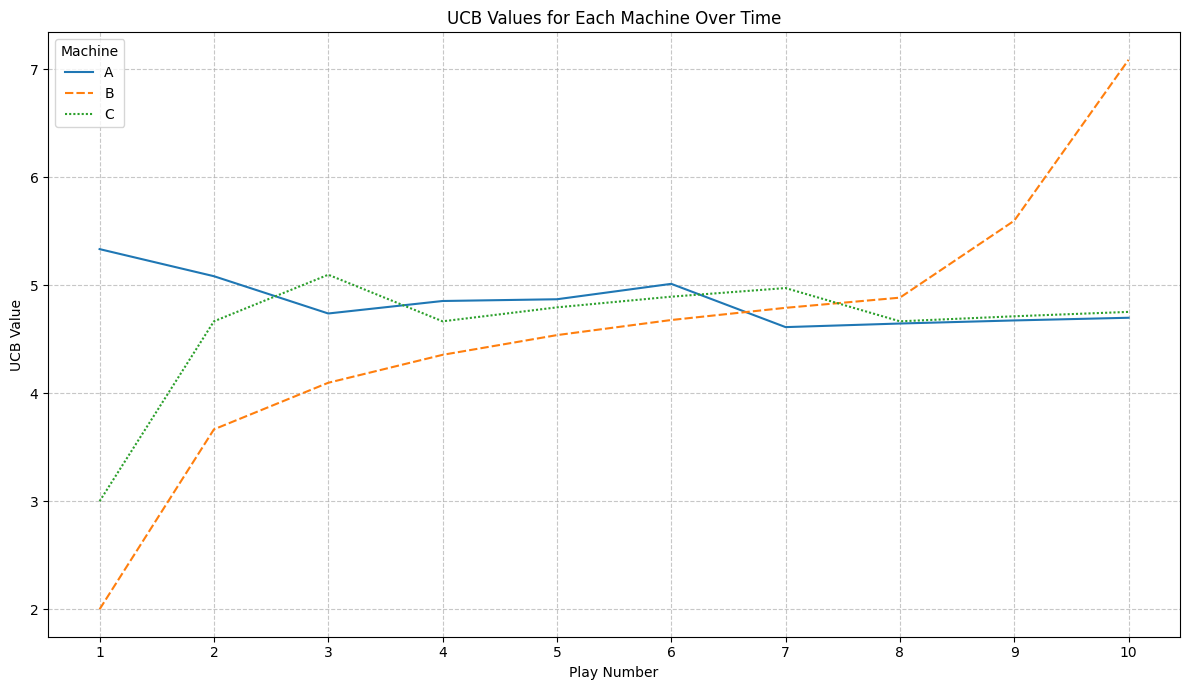

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert ucb_history into a pandas DataFrame for easier plotting
ucb_df = pd.DataFrame(ucb_history)
ucb_df.index = ucb_df.index + 1 # Adjust index to represent play number starting from 1
ucb_df.index.name = 'Play Number'

# Replace inf values with NaN for plotting purposes, if any remained after initial plays
# and then potentially fill them or drop them depending on visualization needs.
# For now, let's keep them as is or replace for visual clarity if needed.
# If a machine's UCB was 'inf' it means it was prioritized for selection.

plt.figure(figsize=(12, 7))
sns.lineplot(data=ucb_df)
plt.title('UCB Values for Each Machine Over Time')
plt.xlabel('Play Number')
plt.ylabel('UCB Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, N_play + 1)) # Ensure all play numbers are shown on x-axis
plt.legend(title='Machine')
plt.tight_layout()
plt.show()